<a href="https://colab.research.google.com/github/GradByte/Characterizing-Network-Traffic-with-Programmable-Data-Planes/blob/main/Characterizing_Network_Traffic_with_Programmable_Data_Planes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Task I — Software-based Traffic Characterization and Statistical Analysis

In [ ]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# Install scapy
!pip install scapy -q

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from scapy.all import rdpcap, IP, TCP, UDP

# Adjust this path to wherever you put it in Drive
PCAP_PATH = '/content/drive/MyDrive/subset_10k.pcap'

packets = rdpcap(PCAP_PATH)
print(f"Total packets loaded: {len(packets)}")

Total packets loaded: 10000


In [ ]:
import pandas as pd

records = []
prev_time = None

for pkt in packets:
    if not pkt.haslayer(IP):
        continue

    timestamp = float(pkt.time)
    size = len(pkt)
    proto = pkt[IP].proto  # 6=TCP, 17=UDP

    iat = timestamp - prev_time if prev_time is not None else 0
    prev_time = timestamp

    src_ip = pkt[IP].src
    dst_ip = pkt[IP].dst
    src_port = pkt[TCP].sport if pkt.haslayer(TCP) else (pkt[UDP].sport if pkt.haslayer(UDP) else None)
    dst_port = pkt[TCP].dport if pkt.haslayer(TCP) else (pkt[UDP].dport if pkt.haslayer(UDP) else None)

    records.append({
        'timestamp': timestamp,
        'size': size,
        'iat': iat,
        'proto': 'TCP' if proto == 6 else ('UDP' if proto == 17 else 'OTHER'),
        'src_ip': src_ip,
        'dst_ip': dst_ip,
        'src_port': src_port,
        'dst_port': dst_port,
    })

df = pd.DataFrame(records)
print(df.head())
print(df.describe())

      timestamp  size       iat  proto           src_ip           dst_ip  \
0  1.359695e+09    54  0.000000    TCP     200.11.79.20  140.198.115.132   
1  1.359695e+09    54  0.000003    TCP     200.11.79.20  140.198.115.132   
2  1.359695e+09    54  0.000003    TCP     200.11.79.20  140.198.115.132   
3  1.359695e+09    42  0.000003  OTHER  167.180.134.255    32.218.92.255   
4  1.359695e+09    66  0.000003    TCP    55.146.64.212   211.83.168.117   

   src_port  dst_port  
0      80.0   52021.0  
1      80.0   52021.0  
2      80.0   52021.0  
3       NaN       NaN  
4   49191.0    3389.0  
          timestamp         size          iat      src_port      dst_port
count  9.496000e+03  9496.000000  9496.000000   8892.000000   8892.000000
mean   1.359695e+09    59.548652     0.000031  21051.369996  31310.267881
std    8.258977e-02    10.636042     0.000058  24583.154988  25688.086635
min    1.359695e+09    34.000000     0.000000     20.000000     21.000000
25%    1.359695e+09    54.000

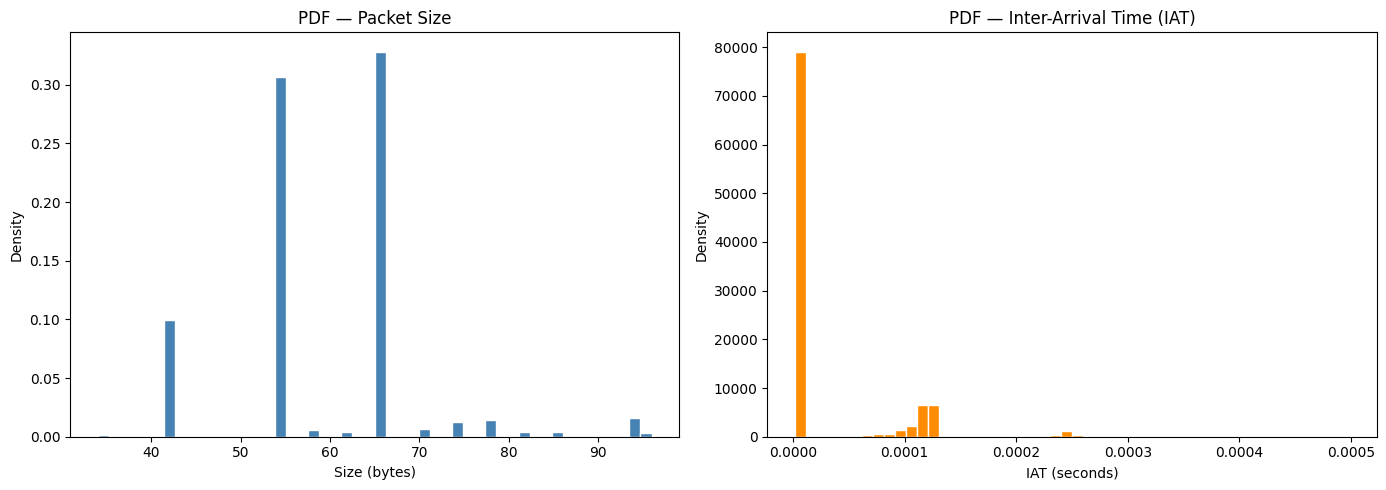

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Packet size PDF
axes[0].hist(df['size'], bins=50, density=True, color='steelblue', edgecolor='white')
axes[0].set_title('PDF — Packet Size')
axes[0].set_xlabel('Size (bytes)')
axes[0].set_ylabel('Density')

# IAT PDF (skip first 0 value)
iat_data = df['iat'][df['iat'] > 0]
axes[1].hist(iat_data, bins=50, density=True, color='darkorange', edgecolor='white')
axes[1].set_title('PDF — Inter-Arrival Time (IAT)')
axes[1].set_xlabel('IAT (seconds)')
axes[1].set_ylabel('Density')

plt.tight_layout()
plt.savefig('pdfs.png', dpi=150)
plt.show()

In [ ]:
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt

iat_data = df['iat'][df['iat'] > 0].values

# Candidate distributions to try
distributions = {
    'Exponential': stats.expon,
    'Log-Normal': stats.lognorm,
    'Weibull': stats.weibull_min,
    'Pareto': stats.pareto,
    'Gamma': stats.gamma,
}

results = []

for name, dist in distributions.items():
    # Fit the distribution
    params = dist.fit(iat_data, floc=0)

    # KS test
    ks_stat, p_value = stats.kstest(iat_data, dist.name, args=params)

    # AIC (lower is better)
    log_likelihood = np.sum(dist.logpdf(iat_data, *params))
    k = len(params)
    aic = 2 * k - 2 * log_likelihood

    results.append({
        'Distribution': name,
        'KS Statistic': round(ks_stat, 4),
        'P-value': round(p_value, 4),
        'AIC': round(aic, 2)
    })
    print(f"{name}: KS={ks_stat:.4f}, p={p_value:.4f}, AIC={aic:.2f}")

results_df = pd.DataFrame(results).sort_values('AIC')
print("\nBest fit (lowest AIC):")
print(results_df.iloc[0])

Exponential: KS=0.5865, p=0.0000, AIC=-178368.38
Log-Normal: KS=0.3250, p=0.0000, AIC=-190261.36
Weibull: KS=0.3374, p=0.0000, AIC=-186388.92
Pareto: KS=0.2146, p=0.0000, AIC=-201261.43
Gamma: KS=0.3905, p=0.0000, AIC=-184505.38

Best fit (lowest AIC):
Distribution       Pareto
KS Statistic       0.2146
P-value               0.0
AIC            -201261.43
Name: 3, dtype: object


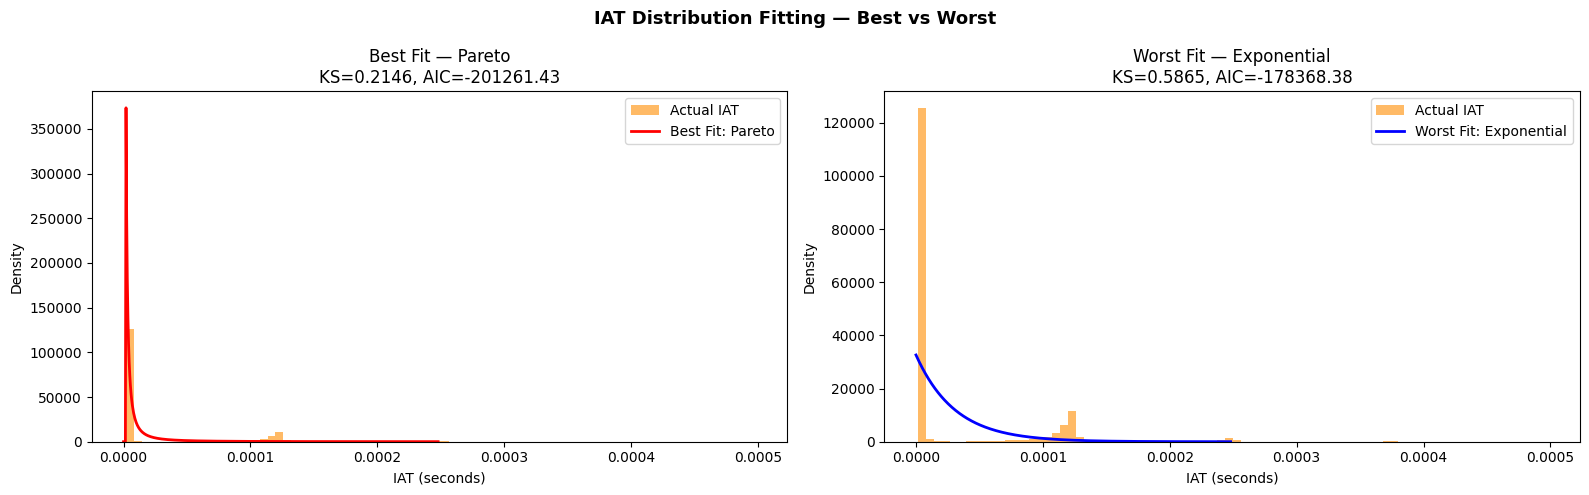

Best:  Pareto  (AIC=-201261.43)
Worst: Exponential (AIC=-178368.38)


In [ ]:
# Re-define best fit variables
best_name = results_df.iloc[0]['Distribution']
best_dist = distributions[best_name]
best_params = best_dist.fit(iat_data, floc=0)

# Automatically pick worst distribution by AIC
worst_name = results_df.iloc[-1]['Distribution']
worst_dist = distributions[worst_name]
worst_params = worst_dist.fit(iat_data, floc=0)

x = np.linspace(0, np.percentile(iat_data, 99), 500)
worst_pdf = worst_dist.pdf(x, *worst_params)
best_pdf = best_dist.pdf(x, *best_params)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Best fit
axes[0].hist(iat_data, bins=80, density=True, alpha=0.6,
             label='Actual IAT', color='darkorange')
axes[0].plot(x, best_pdf, 'r-', linewidth=2,
             label=f'Best Fit: {best_name}')
axes[0].set_title(f'Best Fit — {best_name}\nKS={results_df.iloc[0]["KS Statistic"]}, AIC={results_df.iloc[0]["AIC"]}')
axes[0].set_xlabel('IAT (seconds)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Worst fit
axes[1].hist(iat_data, bins=80, density=True, alpha=0.6,
             label='Actual IAT', color='darkorange')
axes[1].plot(x, worst_pdf, 'b-', linewidth=2,
             label=f'Worst Fit: {worst_name}')
axes[1].set_title(f'Worst Fit — {worst_name}\nKS={results_df.iloc[-1]["KS Statistic"]}, AIC={results_df.iloc[-1]["AIC"]}')
axes[1].set_xlabel('IAT (seconds)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('IAT Distribution Fitting — Best vs Worst', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('best_vs_worst_fit.png', dpi=150)
plt.show()

print(f"Best:  {best_name}  (AIC={results_df.iloc[0]['AIC']})")
print(f"Worst: {worst_name} (AIC={results_df.iloc[-1]['AIC']})")

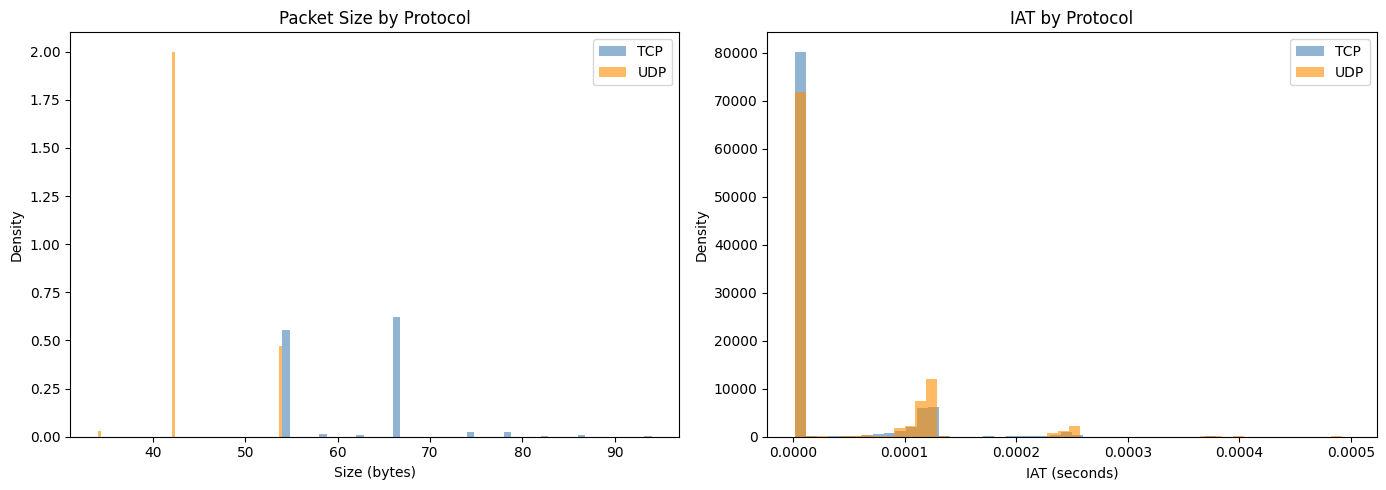

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for proto, color in [('TCP', 'steelblue'), ('UDP', 'darkorange')]:
    subset = df[df['proto'] == proto]['size']
    axes[0].hist(subset, bins=50, density=True, alpha=0.6, label=proto, color=color)

axes[0].set_title('Packet Size by Protocol')
axes[0].set_xlabel('Size (bytes)')
axes[0].set_ylabel('Density')
axes[0].legend()

for proto, color in [('TCP', 'steelblue'), ('UDP', 'darkorange')]:
    subset = df[df['proto'] == proto]['iat']
    subset = subset[subset > 0]
    axes[1].hist(subset, bins=50, density=True, alpha=0.6, label=proto, color=color)

axes[1].set_title('IAT by Protocol')
axes[1].set_xlabel('IAT (seconds)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.tight_layout()
plt.savefig('by_protocol.png', dpi=150)
plt.show()

In [ ]:
# ===== Short vs Long Flow Analysis =====

# First build flow-level dataframe from Task I
flows_analysis = df.groupby(['src_ip', 'dst_ip', 'proto']).agg(
    packet_count=('size', 'count'),
    byte_count=('size', 'sum'),
    avg_pkt_size=('size', 'mean'),
    duration=('timestamp', lambda x: x.max() - x.min())
).reset_index()

# Define short vs long flows by median packet count
median_pkts = flows_analysis['packet_count'].median()
print(f"Median packets per flow: {median_pkts}")
print(f"Total flows: {len(flows_analysis)}")

flows_analysis['flow_type'] = flows_analysis['packet_count'].apply(
    lambda x: 'Long Flow' if x > median_pkts else 'Short Flow'
)

short_flows = flows_analysis[flows_analysis['flow_type'] == 'Short Flow']
long_flows  = flows_analysis[flows_analysis['flow_type'] == 'Long Flow']

print(f"\nShort flows (≤ {median_pkts} packets): {len(short_flows)}")
print(f"Long flows  (> {median_pkts} packets): {len(long_flows)}")

# Summary stats
print(f"\n{'Metric':<25} {'Short Flows':>15} {'Long Flows':>15}")
print("=" * 55)
print(f"{'Avg packet count':<25} {short_flows['packet_count'].mean():>15.1f} {long_flows['packet_count'].mean():>15.1f}")
print(f"{'Avg byte count':<25} {short_flows['byte_count'].mean():>15.1f} {long_flows['byte_count'].mean():>15.1f}")
print(f"{'Avg packet size (bytes)':<25} {short_flows['avg_pkt_size'].mean():>15.1f} {long_flows['avg_pkt_size'].mean():>15.1f}")
print(f"{'Avg duration (s)':<25} {short_flows['duration'].mean():>15.4f} {long_flows['duration'].mean():>15.4f}")

Median packets per flow: 1.0
Total flows: 1507

Short flows (≤ 1.0 packets): 1016
Long flows  (> 1.0 packets): 491

Metric                        Short Flows      Long Flows
Avg packet count                      1.0            17.3
Avg byte count                       50.8          1046.5
Avg packet size (bytes)              50.8            58.4
Avg duration (s)                   0.0000          0.1128


In [ ]:
# Pretty summary table
styled = results_df.sort_values('AIC').reset_index(drop=True)
styled.index += 1  # Start ranking from 1

# Add a rank label
styled.insert(0, 'Rank', range(1, len(styled)+1))

print("=" * 65)
print(f"{'Rank':<6}{'Distribution':<15}{'KS Stat':<12}{'P-value':<12}{'AIC':<15}")
print("=" * 65)
for _, row in styled.iterrows():
    marker = " ← BEST" if row['Rank'] == 1 else (" ← WORST" if row['Rank'] == len(styled) else "")
    print(f"{int(row['Rank']):<6}{row['Distribution']:<15}{row['KS Statistic']:<12}{row['P-value']:<12}{row['AIC']:<15}{marker}")
print("=" * 65)

Rank  Distribution   KS Stat     P-value     AIC            
1     Pareto         0.2146      0.0         -201261.43      ← BEST
2     Log-Normal     0.325       0.0         -190261.36     
3     Weibull        0.3374      0.0         -186388.92     
4     Gamma          0.3905      0.0         -184505.38     
5     Exponential    0.5865      0.0         -178368.38      ← WORST


In [ ]:
import numpy as np
from scipy import stats
import pandas as pd

iat_small = iat_data[:20]  # Take first 20 samples

distributions = {
    'Exponential': stats.expon,
    'Log-Normal': stats.lognorm,
    'Weibull': stats.weibull_min,
    'Pareto': stats.pareto,
    'Gamma': stats.gamma,
}

results_small = []

for name, dist in distributions.items():
    params = dist.fit(iat_small, floc=0)
    ks_stat, p_value = stats.kstest(iat_small, dist.name, args=params)
    log_likelihood = np.sum(dist.logpdf(iat_small, *params))
    k = len(params)
    aic = 2 * k - 2 * log_likelihood
    results_small.append({
        'Distribution': name,
        'KS Statistic': round(ks_stat, 4),
        'P-value': round(p_value, 4),
        'AIC': round(aic, 2)
    })

results_small_df = pd.DataFrame(results_small).sort_values('AIC').reset_index(drop=True)
results_small_df.insert(0, 'Rank', range(1, len(results_small_df)+1))

print("=" * 65)
print(f"SMALL SAMPLE (n=20)")
print("=" * 65)
print(f"{'Rank':<6}{'Distribution':<15}{'KS Stat':<12}{'P-value':<12}{'AIC':<15}")
print("=" * 65)
for _, row in results_small_df.iterrows():
    marker = " ← BEST" if row['Rank'] == 1 else (" ← WORST" if row['Rank'] == len(results_small_df) else "")
    print(f"{int(row['Rank']):<6}{row['Distribution']:<15}{row['KS Statistic']:<12}{row['P-value']:<12}{row['AIC']:<15}{marker}")
print("=" * 65)

# Side by side comparison
print("\n")
print("=" * 65)
print(f"COMPARISON: P-values at n=20 vs n=10000")
print("=" * 65)
print(f"{'Distribution':<15}{'P-value (n=20)':<20}{'P-value (n=10000)':<20}")
print("=" * 65)

results_full_indexed = results_df.set_index('Distribution')
results_small_indexed = results_small_df.set_index('Distribution')

for name in distributions.keys():
    p_small = results_small_indexed.loc[name, 'P-value']
    p_full = results_full_indexed.loc[name, 'P-value']
    print(f"{name:<15}{str(p_small):<20}{str(p_full):<20}")
print("=" * 65)

SMALL SAMPLE (n=20)
Rank  Distribution   KS Stat     P-value     AIC            
1     Pareto         0.2773      0.0751      -422.16         ← BEST
2     Log-Normal     0.3005      0.0425      -399.46        
3     Weibull        0.3231      0.0234      -391.09        
4     Gamma          0.3842      0.0036      -387.53        
5     Exponential    0.5528      0.0         -379.56         ← WORST


COMPARISON: P-values at n=20 vs n=10000
Distribution   P-value (n=20)      P-value (n=10000)   
Exponential    0.0                 0.0                 
Log-Normal     0.0425              0.0                 
Weibull        0.0234              0.0                 
Pareto         0.0751              0.0                 
Gamma          0.0036              0.0                 


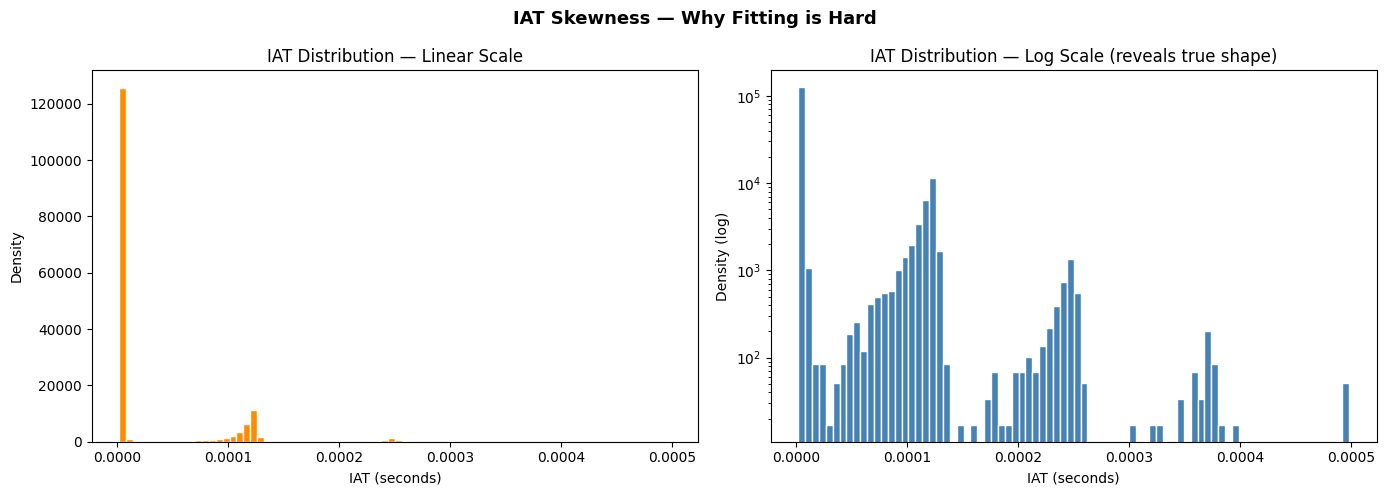

Skewness: 2.4099
(Values above 1.0 are considered highly skewed)


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Normal scale - will look very squished
axes[0].hist(iat_data, bins=80, density=True, color='darkorange', edgecolor='white')
axes[0].set_title('IAT Distribution — Linear Scale')
axes[0].set_xlabel('IAT (seconds)')
axes[0].set_ylabel('Density')

# Log scale - reveals the true shape much better
axes[1].hist(iat_data, bins=80, density=True, color='steelblue', edgecolor='white')
axes[1].set_yscale('log')
axes[1].set_title('IAT Distribution — Log Scale (reveals true shape)')
axes[1].set_xlabel('IAT (seconds)')
axes[1].set_ylabel('Density (log)')

plt.suptitle('IAT Skewness — Why Fitting is Hard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('iat_skew.png', dpi=150)
plt.show()

print(f"Skewness: {stats.skew(iat_data):.4f}")
print(f"(Values above 1.0 are considered highly skewed)")

In [ ]:
np.random.seed(42)  # For reproducibility
iat_small = np.random.choice(iat_data, size=20, replace=False)

results_small = []

for name, dist in distributions.items():
    params = dist.fit(iat_small, floc=0)
    ks_stat, p_value = stats.kstest(iat_small, dist.name, args=params)
    log_likelihood = np.sum(dist.logpdf(iat_small, *params))
    k = len(params)
    aic = 2 * k - 2 * log_likelihood
    results_small.append({
        'Distribution': name,
        'KS Statistic': round(ks_stat, 4),
        'P-value': round(p_value, 4),
        'AIC': round(aic, 2)
    })

results_small_df = pd.DataFrame(results_small).sort_values('AIC').reset_index(drop=True)
results_small_df.insert(0, 'Rank', range(1, len(results_small_df)+1))

print("=" * 65)
print(f"RANDOM SMALL SAMPLE (n=20)")
print("=" * 65)
print(f"{'Rank':<6}{'Distribution':<15}{'KS Stat':<12}{'P-value':<12}{'AIC':<15}")
print("=" * 65)
for _, row in results_small_df.iterrows():
    marker = " ← BEST" if row['Rank'] == 1 else (" ← WORST" if row['Rank'] == len(results_small_df) else "")
    print(f"{int(row['Rank']):<6}{row['Distribution']:<15}{row['KS Statistic']:<12}{row['P-value']:<12}{row['AIC']:<15}{marker}")
print("=" * 65)

# Comparison table
print("\n")
print("=" * 65)
print(f"COMPARISON: P-values at n=20 vs n=10000")
print("=" * 65)
print(f"{'Distribution':<15}{'P-value (n=20)':<20}{'P-value (n=10000)':<20}")
print("=" * 65)
results_full_indexed = results_df.set_index('Distribution')
results_small_indexed = results_small_df.set_index('Distribution')
for name in distributions.keys():
    p_small = results_small_indexed.loc[name, 'P-value']
    p_full = results_full_indexed.loc[name, 'P-value']
    print(f"{name:<15}{str(p_small):<20}{str(p_full):<20}")
print("=" * 65)

RANDOM SMALL SAMPLE (n=20)
Rank  Distribution   KS Stat     P-value     AIC            
1     Pareto         0.2686      0.0916      -420.2          ← BEST
2     Log-Normal     0.376       0.0048      -394.12        
3     Weibull        0.3894      0.0031      -385.37        
4     Gamma          0.448       0.0004      -380.68        
5     Exponential    0.6704      0.0         -365.21         ← WORST


COMPARISON: P-values at n=20 vs n=10000
Distribution   P-value (n=20)      P-value (n=10000)   
Exponential    0.0                 0.0                 
Log-Normal     0.0048              0.0                 
Weibull        0.0031              0.0                 
Pareto         0.0916              0.0                 
Gamma          0.0004              0.0                 


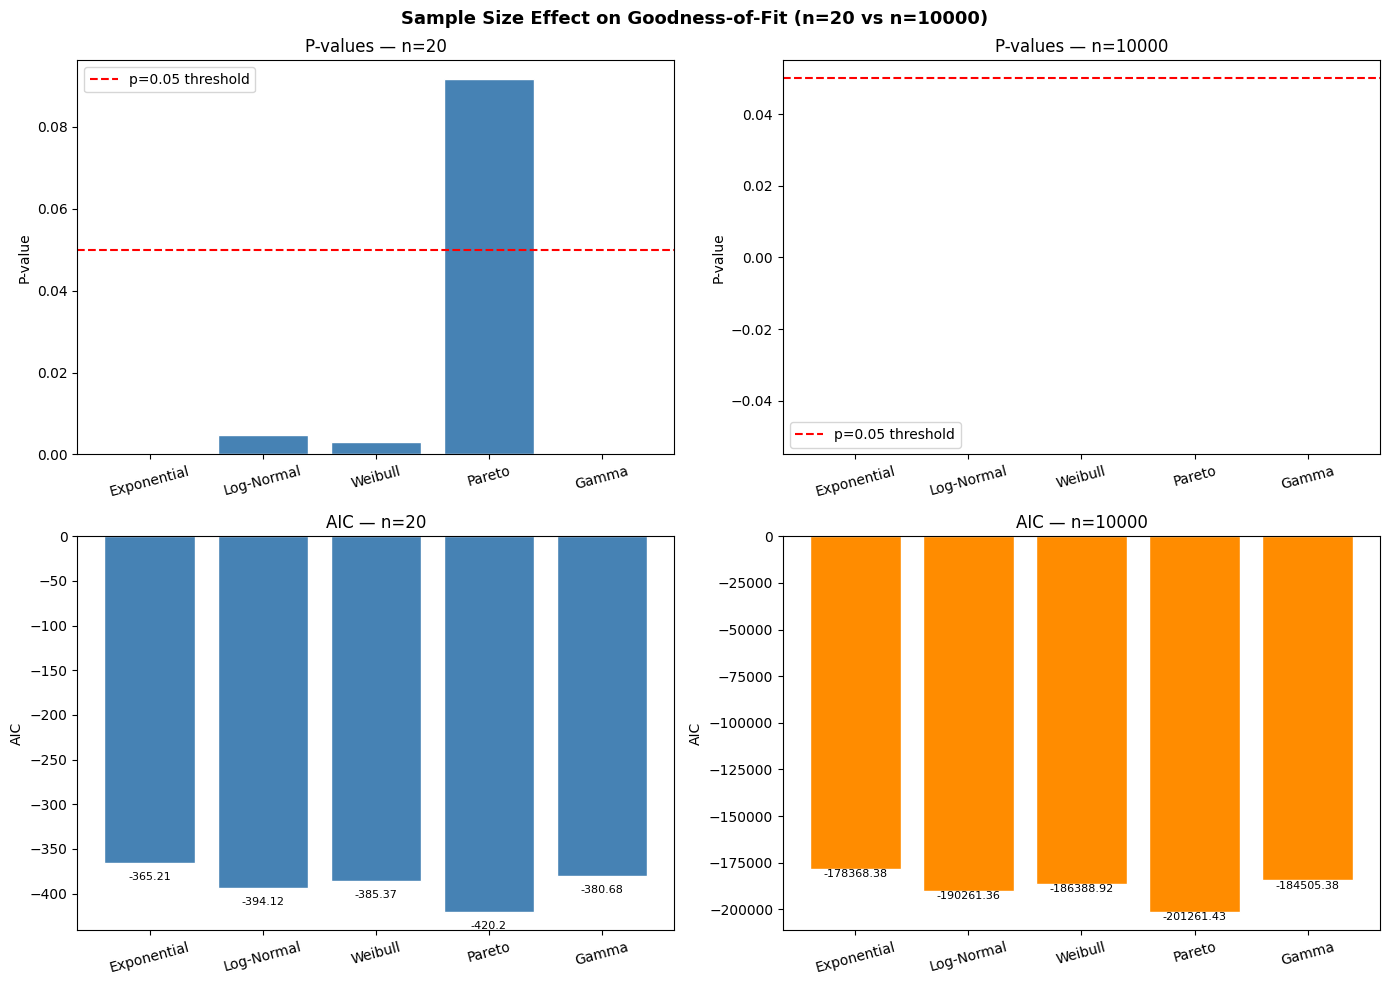

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

distributions_list = ['Exponential', 'Log-Normal', 'Weibull', 'Pareto', 'Gamma']
p_small = [results_small_indexed.loc[d, 'P-value'] for d in distributions_list]
p_full = [results_full_indexed.loc[d, 'P-value'] for d in distributions_list]
aic_small = [results_small_indexed.loc[d, 'AIC'] for d in distributions_list]
aic_full = [results_full_indexed.loc[d, 'AIC'] for d in distributions_list]

x = np.arange(len(distributions_list))

# --- Row 1: P-values ---
# n=20 p-value
axes[0, 0].bar(x, p_small, color='steelblue', edgecolor='white')
axes[0, 0].axhline(y=0.05, color='red', linestyle='--', label='p=0.05 threshold')
axes[0, 0].set_title('P-values — n=20')
axes[0, 0].set_ylabel('P-value')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(distributions_list, rotation=15)
axes[0, 0].legend()

# n=10000 p-value
axes[0, 1].bar(x, p_full, color='darkorange', edgecolor='white')
axes[0, 1].axhline(y=0.05, color='red', linestyle='--', label='p=0.05 threshold')
axes[0, 1].set_title('P-values — n=10000')
axes[0, 1].set_ylabel('P-value')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(distributions_list, rotation=15)
axes[0, 1].legend()

# --- Row 2: AIC (each on its own scale) ---
# n=20 AIC
axes[1, 0].bar(x, aic_small, color='steelblue', edgecolor='white')
axes[1, 0].set_title('AIC — n=20')
axes[1, 0].set_ylabel('AIC')
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(distributions_list, rotation=15)
for i, v in enumerate(aic_small):
    axes[1, 0].text(i, v - 10, str(v), ha='center', va='top', fontsize=8)

# n=10000 AIC
axes[1, 1].bar(x, aic_full, color='darkorange', edgecolor='white')
axes[1, 1].set_title('AIC — n=10000')
axes[1, 1].set_ylabel('AIC')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels(distributions_list, rotation=15)
for i, v in enumerate(aic_full):
    axes[1, 1].text(i, v - 100, str(v), ha='center', va='top', fontsize=8)

plt.suptitle('Sample Size Effect on Goodness-of-Fit (n=20 vs n=10000)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('sample_size_comparison.png', dpi=150)
plt.show()

In [ ]:
# Task I results summary for comparison
import numpy as np

print("Task I (Software/Python) Results:")
print(f"  Total packets     : {len(df)}")
print(f"  Avg packet size   : {df['size'].mean():.1f} bytes")
print(f"  Min packet size   : {df['size'].min():.1f} bytes")
print(f"  Max packet size   : {df['size'].max():.1f} bytes")

# Flow level stats from Task I
flows_t1 = df.groupby(['src_ip', 'dst_ip', 'proto']).agg(
    packet_count=('size', 'count'),
    byte_count=('size', 'sum'),
    avg_pkt_size=('size', 'mean')
).reset_index()

print(f"  Active flows      : {len(flows_t1)}")
print(f"  Avg pkt size/flow : {flows_t1['avg_pkt_size'].mean():.1f} bytes")
print(f"  Min avg pkt size  : {flows_t1['avg_pkt_size'].min():.1f} bytes")
print(f"  Max avg pkt size  : {flows_t1['avg_pkt_size'].max():.1f} bytes")

Task I (Software/Python) Results:
  Total packets     : 9496
  Avg packet size   : 59.5 bytes
  Min packet size   : 34.0 bytes
  Max packet size   : 96.0 bytes
  Active flows      : 1507
  Avg pkt size/flow : 53.3 bytes
  Min avg pkt size  : 34.0 bytes
  Max avg pkt size  : 96.0 bytes


#Task II & III — In-Network Feature Extraction using P4 & Comparison of Two Methods



In [ ]:
# Load P4 flow stats from Google Drive
p4_df = pd.read_csv('/content/drive/MyDrive/flow_stats.csv')
print(f"P4 flow stats loaded: {len(p4_df)} flows")
print(p4_df.head())

P4 flow stats loaded: 1219 flows
   flow_id  packet_count  byte_count  avg_pkt_size
0        0             4         268          67.0
1        4             2         100          50.0
2        6             1          42          42.0
3        7             1          42          42.0
4        8             2         108          54.0


Task I  (Python) : [9496, np.float64(59.5), 1507]
Task II (P4)     : [9496, np.float64(53.6), 1219]


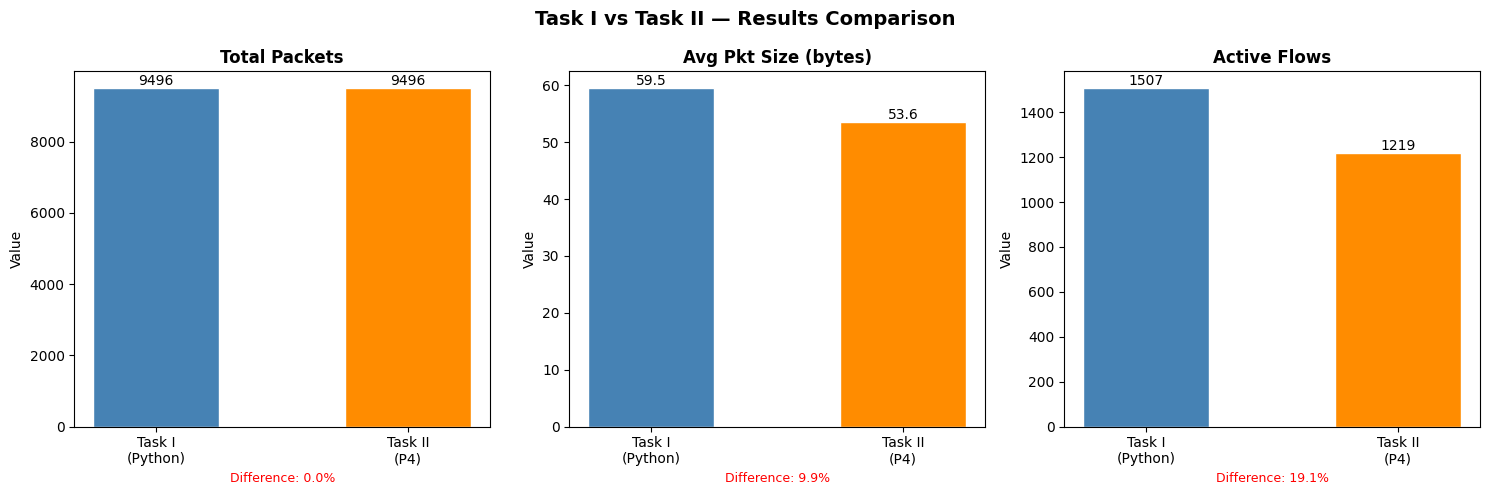

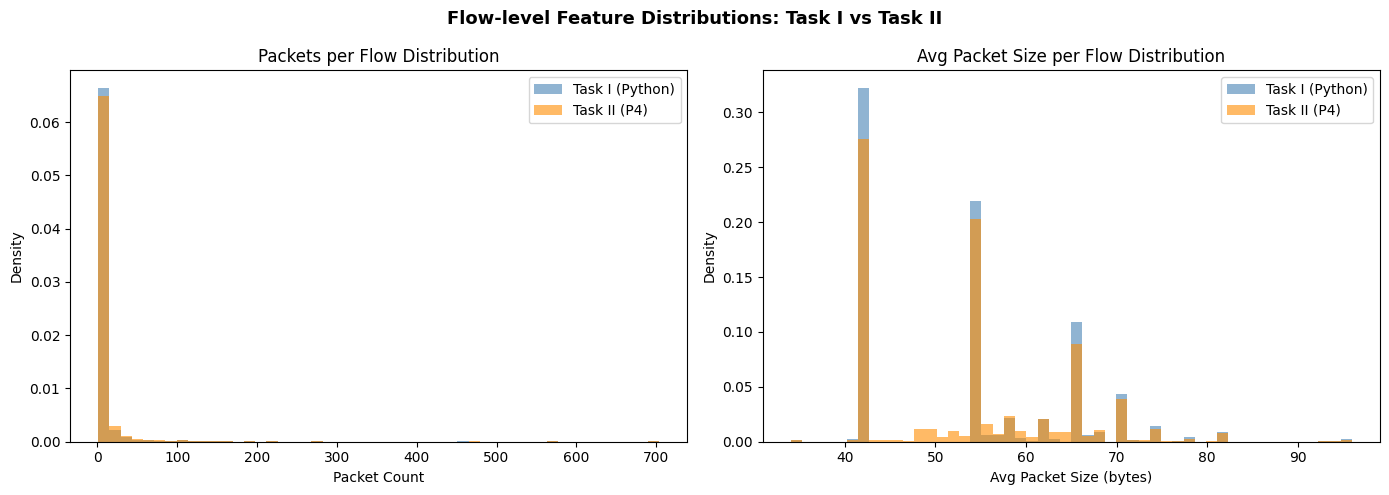

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ===== Compute from actual data =====
task1_total_packets = len(df)
task1_avg_pkt_size  = df['size'].mean()
task1_active_flows  = len(flows_t1)

task2_total_packets = int(p4_df['packet_count'].sum())
task2_avg_pkt_size  = p4_df['avg_pkt_size'].mean()
task2_active_flows  = len(p4_df)

metrics = ['Total Packets', 'Avg Pkt Size (bytes)', 'Active Flows']
task1   = [task1_total_packets, round(task1_avg_pkt_size, 1), task1_active_flows]
task2   = [task2_total_packets, round(task2_avg_pkt_size, 1), task2_active_flows]

print("Task I  (Python) :", task1)
print("Task II (P4)     :", task2)

# ===== Bar Chart =====
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, (metric, v1, v2) in enumerate(zip(metrics, task1, task2)):
    axes[idx].bar(['Task I\n(Python)', 'Task II\n(P4)'], [v1, v2],
                  color=['steelblue', 'darkorange'], edgecolor='white', width=0.5)
    axes[idx].set_title(metric, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].text(0, v1 * 1.01, f'{v1}', ha='center', fontsize=10)
    axes[idx].text(1, v2 * 1.01, f'{v2}', ha='center', fontsize=10)
    diff = abs(v1 - v2) / v1 * 100
    axes[idx].set_xlabel(f'Difference: {diff:.1f}%', color='red', fontsize=9)

plt.suptitle('Task I vs Task II — Results Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('task_comparison.png', dpi=150)
plt.show()

# ===== Flow-level distribution comparison =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(flows_t1['packet_count'], bins=50, density=True,
             alpha=0.6, color='steelblue', label='Task I (Python)')
axes[0].hist(p4_df['packet_count'], bins=50, density=True,
             alpha=0.6, color='darkorange', label='Task II (P4)')
axes[0].set_title('Packets per Flow Distribution')
axes[0].set_xlabel('Packet Count')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(flows_t1['avg_pkt_size'], bins=50, density=True,
             alpha=0.6, color='steelblue', label='Task I (Python)')
axes[1].hist(p4_df['avg_pkt_size'], bins=50, density=True,
             alpha=0.6, color='darkorange', label='Task II (P4)')
axes[1].set_title('Avg Packet Size per Flow Distribution')
axes[1].set_xlabel('Avg Packet Size (bytes)')
axes[1].set_ylabel('Density')
axes[1].legend()

plt.suptitle('Flow-level Feature Distributions: Task I vs Task II',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('flow_distributions_comparison.png', dpi=150)
plt.show()

In [ ]:
# Load P4 IAT samples from Google Drive
iat_p4_df = pd.read_csv('/content/drive/MyDrive/iat_samples.csv')
print(f"P4 IAT samples loaded: {len(iat_p4_df)} samples")
print(iat_p4_df.head())

P4 IAT samples loaded: 9496 samples
     iat_us
0  11481767
1       300
2       242
3       281
4       324


IAT Comparison (in microseconds):
Metric                    Task I (Python)         Task II (P4)     Diff %
Count                             9495.00              9495.00       0.0%
Mean (us)                           30.65                31.02       1.2%
Median (us)                          3.10                 3.59      15.8%
Min (us)                             1.91                 0.06      96.9%
Max (us)                           498.06               658.42      32.2%
Std (us)                            57.76                58.43       1.2%


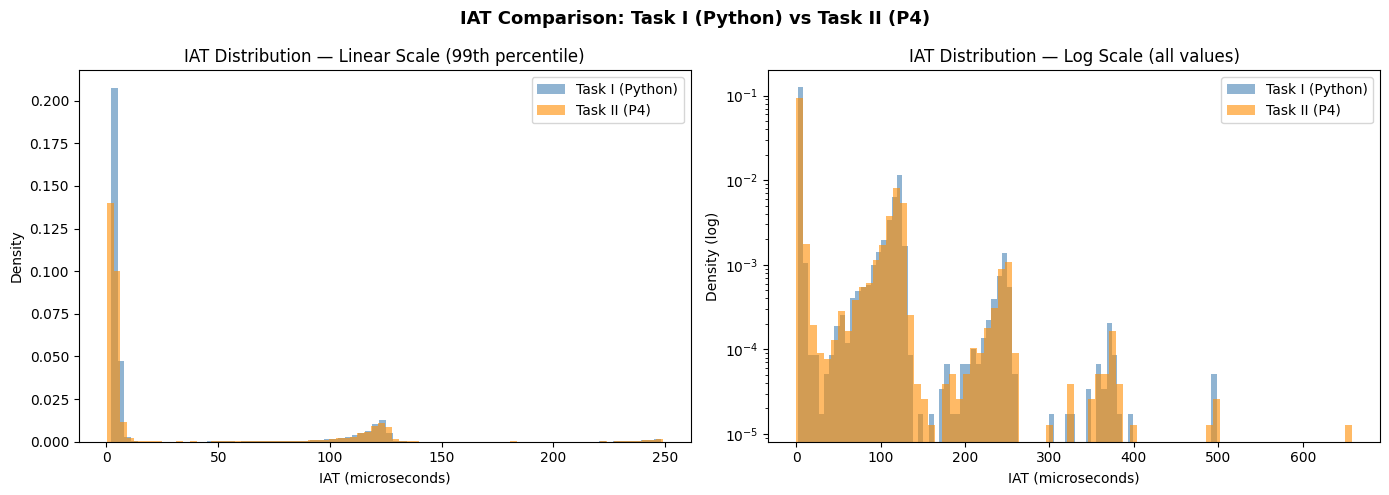

In [ ]:
# Scale down P4 timestamps to account for tcpreplay slowdown (multiplier 0.01)
# Because traffic was replayed 100x slower, we divide by 100 to restore the original timing
iat_task2_us = iat_p4_df['iat_us'][iat_p4_df['iat_us'] > 0].values / 100
iat_task2_us = iat_task2_us[1:]

# Convert Task I (Scapy/PCAP) ground truth from seconds to microseconds
iat_task1_us = df['iat'][df['iat'] > 0].values * 1_000_000

print("IAT Comparison (in microseconds):")
print(f"{'Metric':<20} {'Task I (Python)':>20} {'Task II (P4)':>20} {'Diff %':>10}")
print("=" * 72)

metrics_iat = {
    'Count'       : (len(iat_task1_us),            len(iat_task2_us)),
    'Mean (us)'   : (iat_task1_us.mean(),           iat_task2_us.mean()),
    'Median (us)' : (np.median(iat_task1_us),       np.median(iat_task2_us)),
    'Min (us)'    : (iat_task1_us.min(),            iat_task2_us.min()),
    'Max (us)'    : (iat_task1_us.max(),            iat_task2_us.max()),
    'Std (us)'    : (iat_task1_us.std(),            iat_task2_us.std()),
}

for metric, (v1, v2) in metrics_iat.items():
    diff = abs(v1 - v2) / v1 * 100
    print(f"{metric:<20} {v1:>20.2f} {v2:>20.2f} {diff:>9.1f}%")

# ===== Plot =====
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

p99_t1 = np.percentile(iat_task1_us, 99)
p99_t2 = np.percentile(iat_task2_us, 99)
x_max  = max(p99_t1, p99_t2)

axes[0].hist(iat_task1_us[iat_task1_us <= x_max], bins=80, density=True,
             alpha=0.6, color='steelblue', label='Task I (Python)')
axes[0].hist(iat_task2_us[iat_task2_us <= x_max], bins=80, density=True,
             alpha=0.6, color='darkorange', label='Task II (P4)')
axes[0].set_title('IAT Distribution — Linear Scale (99th percentile)')
axes[0].set_xlabel('IAT (microseconds)')
axes[0].set_ylabel('Density')
axes[0].legend()

axes[1].hist(iat_task1_us, bins=80, density=True,
             alpha=0.6, color='steelblue', label='Task I (Python)')
axes[1].hist(iat_task2_us, bins=80, density=True,
             alpha=0.6, color='darkorange', label='Task II (P4)')
axes[1].set_yscale('log')
axes[1].set_title('IAT Distribution — Log Scale (all values)')
axes[1].set_xlabel('IAT (microseconds)')
axes[1].set_ylabel('Density (log)')
axes[1].legend()

plt.suptitle('IAT Comparison: Task I (Python) vs Task II (P4)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('iat_comparison.png', dpi=150)
plt.show()